In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\bisha\OneDrive\Documents\GitHub\Sales-analysis/data.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [5]:
#Convert order date and ship date in correct data type
df['Order Date']=pd.to_datetime(df['Order Date'],format="%d/%m/%Y")
df['Ship Date']=pd.to_datetime(df['Ship Date'],format="%d/%m/%Y")

In [6]:
# Season function
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

# Extract features for both columns
for col in ["Order Date", "Ship Date"]:
    prefix = col.replace(" ", "_")  # Order_Date, Ship_Date

    df[f"{prefix}_Year"] = df[col].dt.year
    df[f"{prefix}_Month"] = df[col].dt.month
    df[f"{prefix}_Week_Number"] = df[col].dt.isocalendar().week
    df[f"{prefix}_Day_of_Week"] = df[col].dt.dayofweek
    df[f"{prefix}_Quarter"] = df[col].dt.quarter
    df[f"{prefix}_Season"] = df[col].dt.month.apply(get_season)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Row ID                  9800 non-null   int64         
 1   Order ID                9800 non-null   object        
 2   Order Date              9800 non-null   datetime64[ns]
 3   Ship Date               9800 non-null   datetime64[ns]
 4   Ship Mode               9800 non-null   object        
 5   Customer ID             9800 non-null   object        
 6   Customer Name           9800 non-null   object        
 7   Segment                 9800 non-null   object        
 8   Country                 9800 non-null   object        
 9   City                    9800 non-null   object        
 10  State                   9800 non-null   object        
 11  Postal Code             9789 non-null   float64       
 12  Region                  9800 non-null   object  

In [8]:
# Checking for duplicate values
df.duplicated().sum()

0

Now data is clean. It do not contain any null values, duplicate values and no wrong data types.

In [9]:
#Extraction of year and month
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

In [10]:
#Weekly sales
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

print(weekly_sales.head())

  Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914


In [11]:
#Monthly sales
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
      .sum()
)

print(monthly_sales.head())

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64


C:\Users\bisha\AppData\Local\Temp\ipykernel_30128\3020764055.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]


#Apply Time Series Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",   # use "multiplicative" if seasonal fluctuations grow with sales
    period=12           # 12 months in a year
)

#Plot all four components
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle("Time Series Decomposition of Monthly Sales", fontsize=16)
plt.tight_layout()
plt.show()

### Observations:-
- Observation 1 – Trend

The trend component shows the long-term movement in monthly sales. An upward trend indicates that overall sales have grown steadily over the four-year  period, while a downward trend would indicate declining sales.

- Observation 2 – Seasonality

The seasonal component reveals a repeating yearly pattern. If the same months consistently show positive seasonal values and the pattern repeats each year, then seasonality is strong. Otherwise, the seasonal effect is relatively weak.

- Observation 3 – Residual (Noise)

The residual component represents random fluctuations that cannot be explained by trend or seasonality. Large positive or negative spikes indicate months where unusual events such as promotions, holidays, or external factors affected sales.

- Observation 4 – Overall

Most of the variation in sales is explained by the combination of trend and seasonal effects, while the residual component captures irregular short-term variations.

## Checking for seasonality


# Some insights from data

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


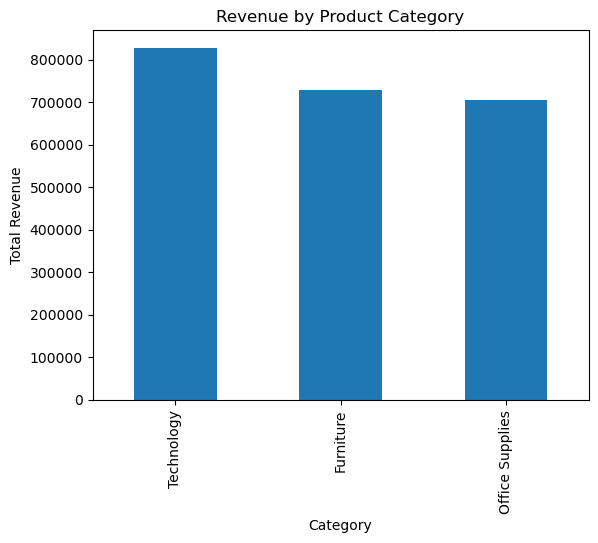

In [12]:
#Extracting high sales
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

#Visualisation
category_sales.plot(kind="bar")
plt.ylabel("Total Revenue")
plt.title("Revenue by Product Category")
plt.show()

Technology generated the highest total revenue with **827455.8730**, followed by Furniture and Office Supplies.

In [13]:
#Finding region who shows consistent growth
yearly_region_sales = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .reset_index()
)

pivot = yearly_region_sales.pivot(
    index="Year",
    columns="Region",
    values="Sales"
)

print(pivot)

Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255


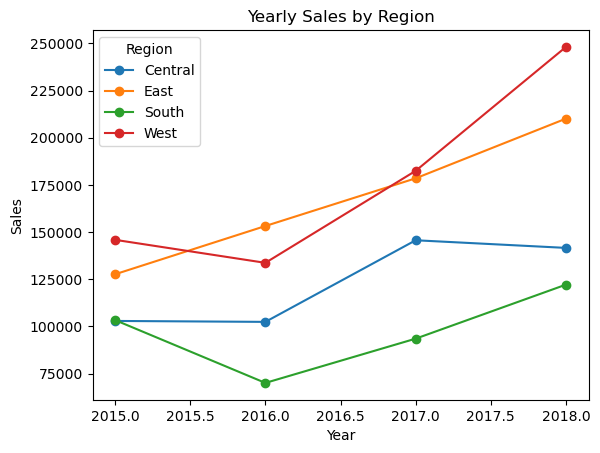

In [14]:
#Visualisation
pivot.plot(marker="o")
plt.ylabel("Sales")
plt.title("Yearly Sales by Region")
plt.show()

- The East region shows regular growth in sales during the intervals.
- West region sales has dropped from 2015 to 2016, but then it shows regular growth and even high sales in 2017 and 2018.
- While the south region has low sales in all 4 year.

## Finding Low gap between order date and ship date for different regions

In [15]:
#Finding shipping days
df["Shipping_Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

print(df["Shipping_Days"].mean())

#Average by region
shipping_region = (
    df.groupby("Region")["Shipping_Days"]
      .mean()
      .sort_values()
)

print(shipping_region)

3.9611224489795918
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping_Days, dtype: float64


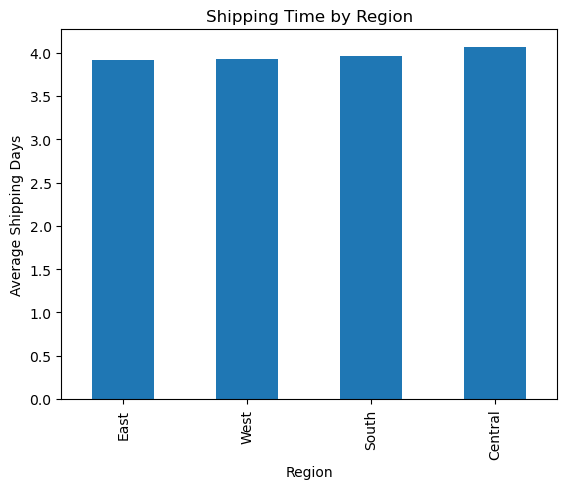

In [16]:
#Visualisation
shipping_region.plot(kind="bar")
plt.ylabel("Average Shipping Days")
plt.title("Shipping Time by Region")
plt.show()

The average shipping time is 4 days. The East region has the fastest delivery, whereas the Central region takes the longest. But there is small change, so we can infer that shipping days do not depend on the region.

### Checking seasonality

In [17]:
#Creation of monthly sales report
monthly_sales = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

#pivot table
pivot = monthly_sales.pivot(
    index="Month",
    columns="Year",
    values="Sales"
)

print(pivot)

Year         2015        2016        2017         2018
Month                                                 
1      14205.7070  18066.9576  18542.4910   43476.4740
2       4519.8920  11951.4110  22978.8150   19920.9974
3      55205.7970  32339.3184  51165.0590   58863.4128
4      27906.8550  34154.4685  38679.7670   35541.9101
5      23644.3030  29959.5305  56656.9080   43825.9822
6      34322.9356  23599.3740  39724.4860   48190.7277
7      33781.5430  28608.2590  38320.7830   44825.1040
8      27117.5365  36818.3422  30542.2003   62837.8480
9      81623.5268  63133.6060  69193.3909   86152.8880
10     31453.3930  31011.7375  59583.0330   77448.1312
11     77907.6607  75249.3995  79066.4958  117938.1550
12     68167.0585  74543.6012  95739.1210   83030.3888


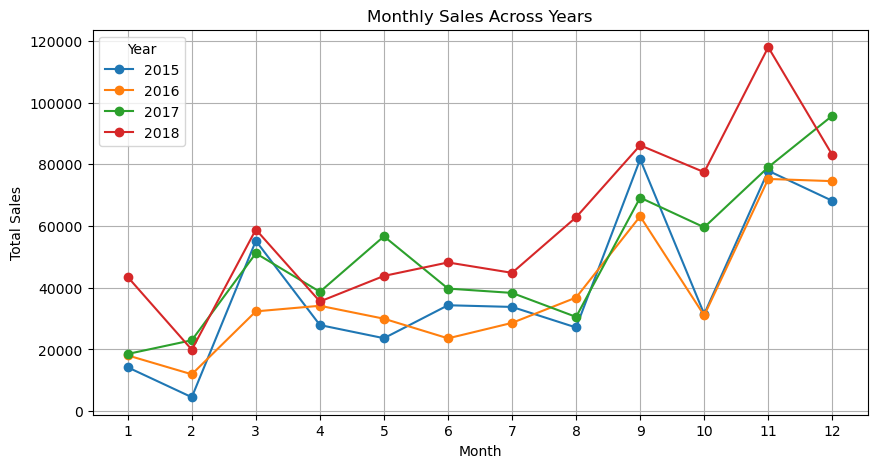

In [18]:
#Visualisation
pivot.plot(marker="o", figsize=(10, 5))
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Across Years")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

We see spike at **March and Septembr**. It show seasonality there.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Row ID                  9800 non-null   int64         
 1   Order ID                9800 non-null   object        
 2   Order Date              9800 non-null   datetime64[ns]
 3   Ship Date               9800 non-null   datetime64[ns]
 4   Ship Mode               9800 non-null   object        
 5   Customer ID             9800 non-null   object        
 6   Customer Name           9800 non-null   object        
 7   Segment                 9800 non-null   object        
 8   Country                 9800 non-null   object        
 9   City                    9800 non-null   object        
 10  State                   9800 non-null   object        
 11  Postal Code             9789 non-null   float64       
 12  Region                  9800 non-null   object  

## Checking for stationarity
Checking for stationarity means whether the statistic(mean, median, etc) of the data over time is stationary or not.

In [20]:
#Perfrom adf test
from statsmodels.tsa.stattools import adfuller

# Perform ADF Test
adf_result = adfuller(monthly_sales['Sales'])

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print("Lags Used     :", adf_result[2])
print("Observations  :", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
p-value       : 0.00027791039276670623
Lags Used     : 0
Observations  : 47

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


Since the p-value<0.05 so we reject the null hypothesise of augment dickey fuller test. It indicates that the monthly sales series is stationary. So we do not re run adf test on difference.

# Model Making:-

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Row ID                  9800 non-null   int64         
 1   Order ID                9800 non-null   object        
 2   Order Date              9800 non-null   datetime64[ns]
 3   Ship Date               9800 non-null   datetime64[ns]
 4   Ship Mode               9800 non-null   object        
 5   Customer ID             9800 non-null   object        
 6   Customer Name           9800 non-null   object        
 7   Segment                 9800 non-null   object        
 8   Country                 9800 non-null   object        
 9   City                    9800 non-null   object        
 10  State                   9800 non-null   object        
 11  Postal Code             9789 non-null   float64       
 12  Region                  9800 non-null   object  

We have so many redundant columns which do not give any important features for analysis like custmer name,row id, order date, postal code. so we remove it.

In [22]:
# removing of redundant information
drop_cols = [
    "Row ID",
    "Order ID",
    "Customer ID",
    "Customer Name",
    "Product ID",
    "Product Name",
    "Postal Code",
    "Ship Date",
    "Year",
    "Month",
    "Ship_Date_Year",
    "Ship_Date_Month",
    "Ship_Date_Week_Number",
    "Ship_Date_Day_of_Week",
    "Ship_Date_Quarter",
    "Ship_Date_Season",
    "Shipping_Days"
]

df_model = df.drop(columns=drop_cols)

In [23]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Order Date              9800 non-null   datetime64[ns]
 1   Ship Mode               9800 non-null   object        
 2   Segment                 9800 non-null   object        
 3   Country                 9800 non-null   object        
 4   City                    9800 non-null   object        
 5   State                   9800 non-null   object        
 6   Region                  9800 non-null   object        
 7   Category                9800 non-null   object        
 8   Sub-Category            9800 non-null   object        
 9   Sales                   9800 non-null   float64       
 10  Order_Date_Year         9800 non-null   int32         
 11  Order_Date_Month        9800 non-null   int32         
 12  Order_Date_Week_Number  9800 non-null   UInt32  

In [24]:
#Importing of library
from sklearn.metrics import (mean_absolute_error,mean_squared_error)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

from prophet import Prophet

from xgboost import XGBRegressor

In [25]:
#Create monthly sales analysis
monthly_sales = (
    df_model.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
)

In [26]:
#Split in train and test
train = monthly_sales.iloc[:-3]
test = monthly_sales.iloc[-3:]
print("Training observations :", len(train))
print("Testing observations  :", len(test))

Training observations : 45
Testing observations  : 3


### Evalution and plot Function:-

In [27]:
#Evaluation function for predcting model
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print("=" * 40)
    print("Model Evaluation")
    print("=" * 40)
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAPE : {mape:.2f}%")

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [28]:
#plot function
def plot_forecast(train, test, prediction, title):

    plt.figure(figsize=(12,5))

    plt.plot(train.index, train, label="Train")

    plt.plot(test.index, test, label="Actual", marker="o")

    plt.plot(test.index, prediction, label="Forecast", marker="o")

    plt.title(title)

    plt.xlabel("Date")

    plt.ylabel("Sales")

    plt.legend()

    plt.grid(True)

    plt.show()

In [29]:
#Result for storing all information
results={}

### Sarima Model

In [30]:
#Train the model
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [31]:
#prediction
forecast = sarima_result.get_forecast(steps=len(test))
sarima_pred = forecast.predicted_mean
confidence_interval = forecast.conf_int()

In [32]:
#Evaluation
sarima_metrics = evaluate_model(test, sarima_pred)
results["SARIMA"] = sarima_metrics

Model Evaluation
MAE  : 19244.49
RMSE : 19950.07
MAPE : 20.53%


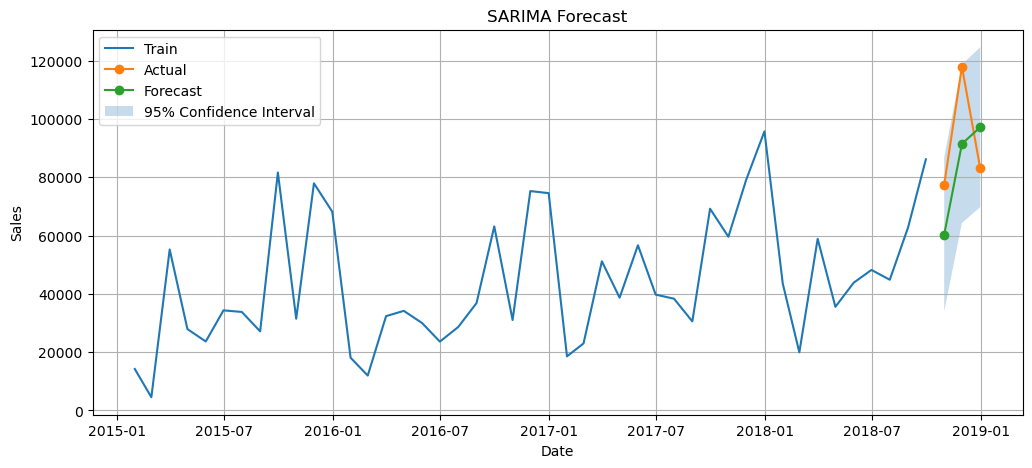

In [33]:
#plot actual vs predicted
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Train")

plt.plot(test.index, test, label="Actual", marker="o")

plt.plot(sarima_pred.index, sarima_pred,
         label="Forecast", marker="o")

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [34]:
#forecast the next month:-
final_sarima = SARIMAX(
    monthly_sales,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [35]:
future = final_sarima.get_forecast(steps=3)

future_sales = future.predicted_mean

future_ci = future.conf_int()

print(future_sales)
results["SARIMA"]["Month 1"] = future_sales.iloc[0]
results["SARIMA"]["Month 2"] = future_sales.iloc[1]
results["SARIMA"]["Month 3"] = future_sales.iloc[2]

2019-01-31    46782.479184
2019-02-28    40285.470514
2019-03-31    72234.203226
Freq: ME, Name: predicted_mean, dtype: float64


In [36]:
#Store future prediction
sarima_future = pd.DataFrame({
    "Forecast": future_sales
})

sarima_future

,Forecast
2019-01-31,46782.479184
2019-02-28,40285.470514
2019-03-31,72234.203226


**Interpreatation**
- The SARIMA model achieved an MAE of 19,244.49, an RMSE of 19,950.07, and a MAPE of 20.53% on the test dataset. A MAPE of approximately 20% indicates that the model's predictions deviate from the actual monthly sales by about one-fifth on average. The similarity between MAE and RMSE suggests that the model does not produce many extreme forecasting errors, although there is still scope for improving prediction accuracy.

### Model Prophet

In [37]:
#Creation of data
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [38]:
#Dividing into test and train
train_prophet = prophet_df.iloc[:-3]
test_prophet = prophet_df.iloc[-3:]

In [39]:
#Training of prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
prophet_model.fit(train_prophet)

02:23:43 - cmdstanpy - INFO - Chain [1] start processing
02:23:44 - cmdstanpy - INFO - Chain [1] done processing


In [40]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

#Generate predictions.
forecast = prophet_model.predict(future)

#Take only the last 3 months.
prophet_pred = forecast.tail(3)["yhat"].values


In [41]:
#Evaluate
#Reuse the evaluation function.
prophet_metrics = evaluate_model(
    test_prophet["y"],
    prophet_pred
)

results["Prophet"] = prophet_metrics

Model Evaluation
MAE  : 20250.77
RMSE : 22318.41
MAPE : 21.86%


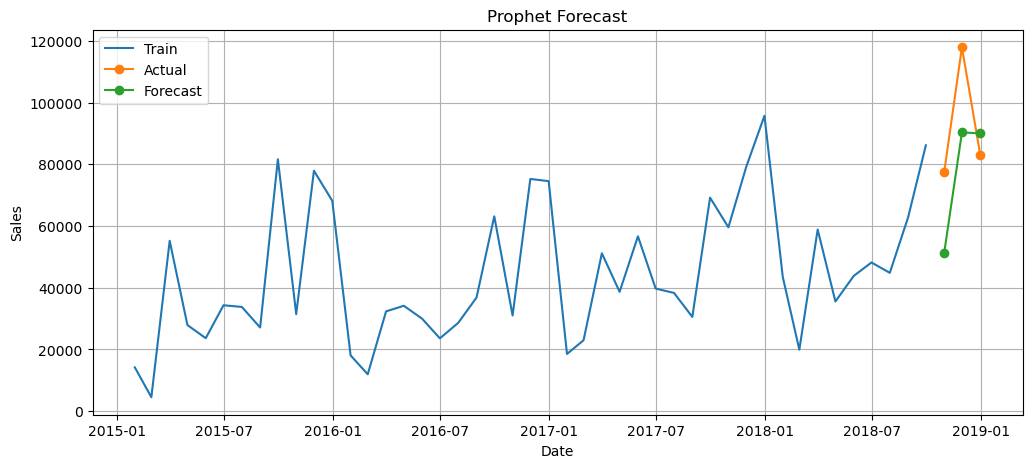

In [42]:
#plot actual vs predicted
plt.figure(figsize=(12,5))

plt.plot(
    train_prophet["ds"],
    train_prophet["y"],
    label="Train"
)

plt.plot(
    test_prophet["ds"],
    test_prophet["y"],
    marker="o",
    label="Actual"
)

plt.plot(
    test_prophet["ds"],
    prophet_pred,
    marker="o",
    label="Forecast"
)

plt.title("Prophet Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [43]:
#Forecast the next three month:-
final_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
final_prophet.fit(prophet_df)

future = final_prophet.make_future_dataframe(
    periods=3,
    freq="ME"
)

future_forecast = final_prophet.predict(future)

#Extract only the future months
future_3 = future_forecast.tail(3)[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]
print(future_3)
results["Prophet"]["Month 1"] = future_3["yhat"].iloc[0]
results["Prophet"]["Month 2"] = future_3["yhat"].iloc[1]
results["Prophet"]["Month 3"] = future_3["yhat"].iloc[2]

02:23:44 - cmdstanpy - INFO - Chain [1] start processing
02:23:45 - cmdstanpy - INFO - Chain [1] done processing


           ds          yhat    yhat_lower    yhat_upper
48 2019-01-31  42990.568530  33241.220708  52274.236217
49 2019-02-28  31248.279349  22065.690367  40627.112111
50 2019-03-31  81267.001856  72078.184929  90218.120748


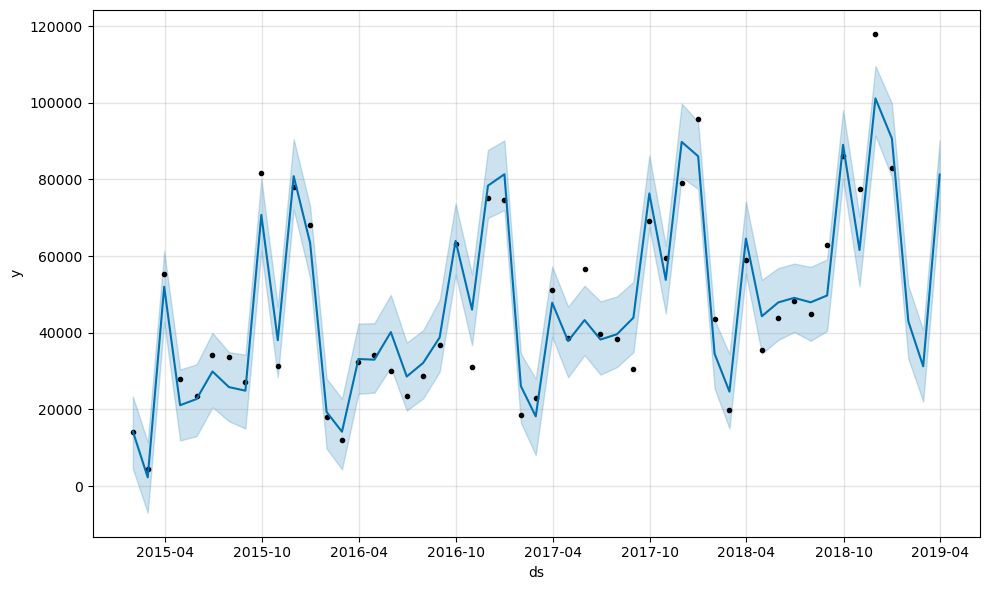

In [44]:
#Use prophet inbuilt graphs to analyse
#Forecast plot:
final_prophet.plot(future_forecast)
plt.show()

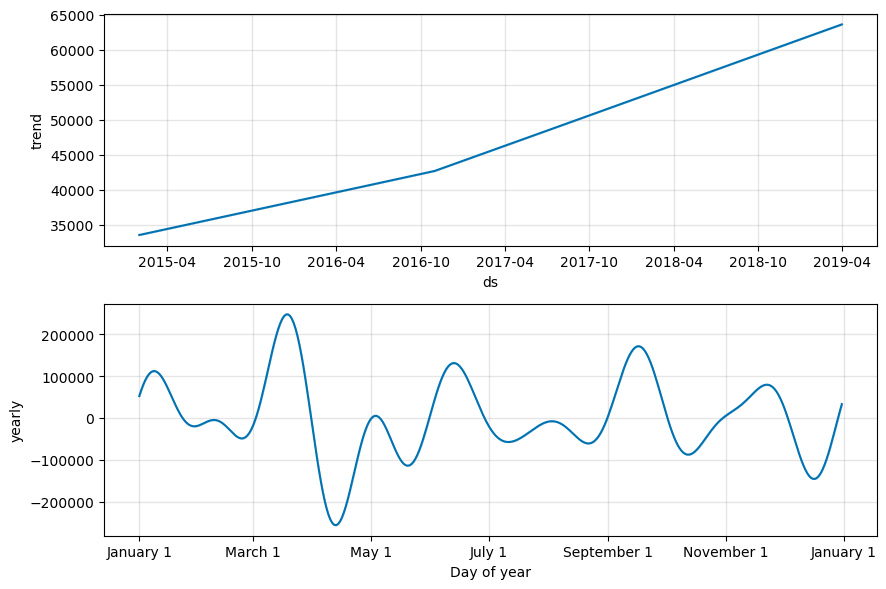

In [45]:
#Trend and seasonality:
final_prophet.plot_components(future_forecast)
plt.show()

**Interpretation**:-
- Prophet models the sales trend using a piecewise linear trend and captures recurring yearly seasonal patterns. Weekly seasonality is disabled because the data is aggregated monthly. The forecast includes uncertainty intervals and provides estimates for the next three months. The trend and seasonality plots help visualize the long-term growth pattern and recurring annual fluctuations.

## XGBOOST

In [46]:
# Create dataframe from monthly sales
xgb_df = monthly_sales.reset_index()

# Rename columns
xgb_df.columns = ["Date", "Sales"]

# Time features
xgb_df["Month"] = xgb_df["Date"].dt.month
xgb_df["Quarter"] = xgb_df["Date"].dt.quarter

# Season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

xgb_df["Season"] = xgb_df["Month"].apply(get_season)

# Lag Features
xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

# Rolling Mean
xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
    .rolling(window=3)
    .mean()
)

# Remove missing rows
xgb_df.dropna(inplace=True)

In [47]:
# One-Hot Encode Season
xgb_df = pd.get_dummies(
    xgb_df,
    columns=["Season"],
    drop_first=True
)

# Features
X = xgb_df.drop(columns=["Date", "Sales"])

# Target
y = xgb_df["Sales"]

# Train-Test Split
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]



In [48]:
# Train Model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Prediction
xgb_pred = xgb_model.predict(X_test)

# Evaluation
xgb_metrics = evaluate_model(y_test, xgb_pred)

results["XGBoost"] = xgb_metrics


Model Evaluation
MAE  : 15159.04
RMSE : 18504.98
MAPE : 15.00%


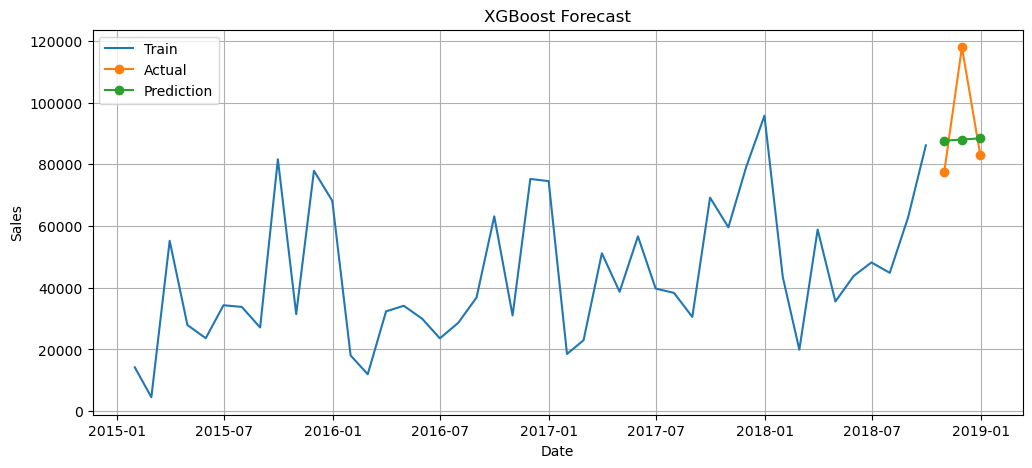

In [49]:
# Plot
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index[:-3],
    monthly_sales.iloc[:-3],
    label="Train"
)

plt.plot(
    monthly_sales.index[-3:],
    y_test,
    marker="o",
    label="Actual"
)

plt.plot(
    monthly_sales.index[-3:],
    xgb_pred,
    marker="o",
    label="Prediction"
)

plt.title("XGBoost Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [50]:
# Forecast Next 3 Months
future_df = xgb_df.copy()

future_predictions = []

for i in range(3):

    last = future_df.iloc[-1].copy()

    lag1 = last["Sales"]
    lag2 = future_df.iloc[-2]["Sales"]
    lag3 = future_df.iloc[-3]["Sales"]

    rolling = (lag1 + lag2 + lag3) / 3

    month = (last["Month"] % 12) + 1

    quarter = ((month - 1) // 3) + 1

    season = get_season(month)

    row = {
        "Month": month,
        "Quarter": quarter,
        "Lag_1": lag1,
        "Lag_2": lag2,
        "Lag_3": lag3,
        "Rolling_Mean_3": rolling,
        "Season_Spring": 1 if season == "Spring" else 0,
        "Season_Summer": 1 if season == "Summer" else 0,
        "Season_Winter": 1 if season == "Winter" else 0
    }

    row = pd.DataFrame([row])

    prediction = xgb_model.predict(row)[0]

    future_predictions.append(prediction)

    new_row = {
        "Date": last["Date"] + pd.offsets.MonthEnd(1),
        "Sales": prediction,
        "Month": month,
        "Quarter": quarter,
        "Season_Autumn": 1 if season == "Autumn" else 0,
        "Season_Spring": row["Season_Spring"].iloc[0],
        "Season_Summer": row["Season_Summer"].iloc[0],
        "Season_Winter": row["Season_Winter"].iloc[0],
        "Lag_1": lag1,
        "Lag_2": lag2,
        "Lag_3": lag3,
        "Rolling_Mean_3": rolling
    }

    future_df = pd.concat(
        [future_df, pd.DataFrame([new_row])],
        ignore_index=True
    )
# Create Forecast Table
forecast_df = pd.DataFrame({
    "Month": ["Month 1", "Month 2", "Month 3"],
    "Forecast": future_predictions
})

print(forecast_df)
results["XGBoost"]["Month 1"] = future_predictions[0]
results["XGBoost"]["Month 2"] = future_predictions[1]
results["XGBoost"]["Month 3"] = future_predictions[2]

     Month      Forecast
0  Month 1  49787.222656
1  Month 2  29234.208984
2  Month 3  61258.527344


### Final comparision table for model


In [51]:
#Creation of comparision table
comparison_table = pd.DataFrame(results).T
comparison_table = comparison_table[["MAE","RMSE","MAPE","Month 1","Month 2","Month 3"]]
comparison_table

,MAE,RMSE,MAPE,Month 1,Month 2,Month 3
SARIMA,19244.485344,19950.070420,20.526432,46782.479184,40285.470514,72234.203226
Prophet,20250.771563,22318.406795,21.864596,42990.568530,31248.279349,81267.001856
XGBoost,15159.045000,18504.982942,14.999103,49787.222656,29234.208984,61258.527344


## Overall Comparison
- SARIMA performed better than Prophet and served as a strong traditional statistical forecasting model.
- Prophet was easy to implement and offered useful visualizations of trend and seasonality, but its prediction accuracy was lower.
- XGBoost consistently outperformed both SARIMA and Prophet across all evaluation metrics, demonstrating the advantage of machine learning when informative lag-based features are available.
-Based on the quantitative evaluation, XGBoost is the recommended model for production deployment.
### Reasons
- It achieved the lowest MAE (15,159.05), indicating the smallest average prediction error.
- It recorded the lowest RMSE (18,504.98), showing better handling of large forecasting errors.
- Its MAPE of approximately 15.00% was significantly lower than SARIMA (20.53%) and Prophet (21.86%), making it the most accurate model overall.
- The model effectively leveraged lag features and rolling averages to capture temporal patterns in the sales data.

## Product Cateogory and Region Level Forecasting

In [52]:
# Monthly Sales for each Category
furniture_monthly = (
    df[df["Category"] == "Furniture"]
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
)

technology_monthly = (
    df[df["Category"] == "Technology"]
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
)

office_monthly = (
    df[df["Category"] == "Office Supplies"]
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
)

# Monthly Sales for each Region
west_monthly = (
    df[df["Region"] == "West"]
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
)

east_monthly = (
    df[df["Region"] == "East"]
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
)

In [53]:
#One Function for XGBoost Forecasting
def xgboost_forecast(monthly_sales):

    # Create dataframe
    xgb_df = monthly_sales.reset_index()
    xgb_df.columns = ["Date", "Sales"]

    # Time Features
    xgb_df["Month"] = xgb_df["Date"].dt.month
    xgb_df["Quarter"] = xgb_df["Date"].dt.quarter

    # Season
    xgb_df["Season"] = xgb_df["Month"].apply(get_season)

    # Lag Features
    xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
    xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
    xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

    xgb_df["Rolling_Mean_3"] = (
        xgb_df["Sales"]
        .rolling(3)
        .mean()
    )

    xgb_df.dropna(inplace=True)

    # Dummy Encoding
    xgb_df = pd.get_dummies(
        xgb_df,
        columns=["Season"],
        drop_first=True
    )

    # Features
    X = xgb_df.drop(columns=["Date", "Sales"])

    y = xgb_df["Sales"]

    # Train Model on ALL available data
    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)

    # Recursive Forecast
    future = xgb_df.copy()

    forecasts = []

    for _ in range(3):

        last = future.iloc[-1]

        lag1 = last["Sales"]
        lag2 = future.iloc[-2]["Sales"]
        lag3 = future.iloc[-3]["Sales"]

        rolling = (lag1 + lag2 + lag3) / 3

        month = (last["Month"] % 12) + 1
        quarter = ((month - 1) // 3) + 1
        season = get_season(month)

        row = pd.DataFrame({
            "Month": [month],
            "Quarter": [quarter],
            "Lag_1": [lag1],
            "Lag_2": [lag2],
            "Lag_3": [lag3],
            "Rolling_Mean_3": [rolling],
            "Season_Spring": [1 if season=="Spring" else 0],
            "Season_Summer": [1 if season=="Summer" else 0],
            "Season_Winter": [1 if season=="Winter" else 0]
        })

        pred = model.predict(row)[0]

        forecasts.append(pred)

        new_row = {
            "Date": last["Date"] + pd.offsets.MonthEnd(1),
            "Sales": pred,
            "Month": month,
            "Quarter": quarter,
            "Lag_1": lag1,
            "Lag_2": lag2,
            "Lag_3": lag3,
            "Rolling_Mean_3": rolling,
            "Season_Spring": row["Season_Spring"].iloc[0],
            "Season_Summer": row["Season_Summer"].iloc[0],
            "Season_Winter": row["Season_Winter"].iloc[0]
        }

        future = pd.concat(
            [future, pd.DataFrame([new_row])],
            ignore_index=True
        )

    return forecasts

,Month,Furniture,Technology,Office Supplies,West,East
0,Month 1,9811.051758,16960.341797,26653.433594,11280.677734,25298.626953
1,Month 2,6064.077148,24378.560547,24821.796875,14821.622070,25576.703125
2,Month 3,17227.724609,23066.167969,29942.798828,23026.916016,28915.763672


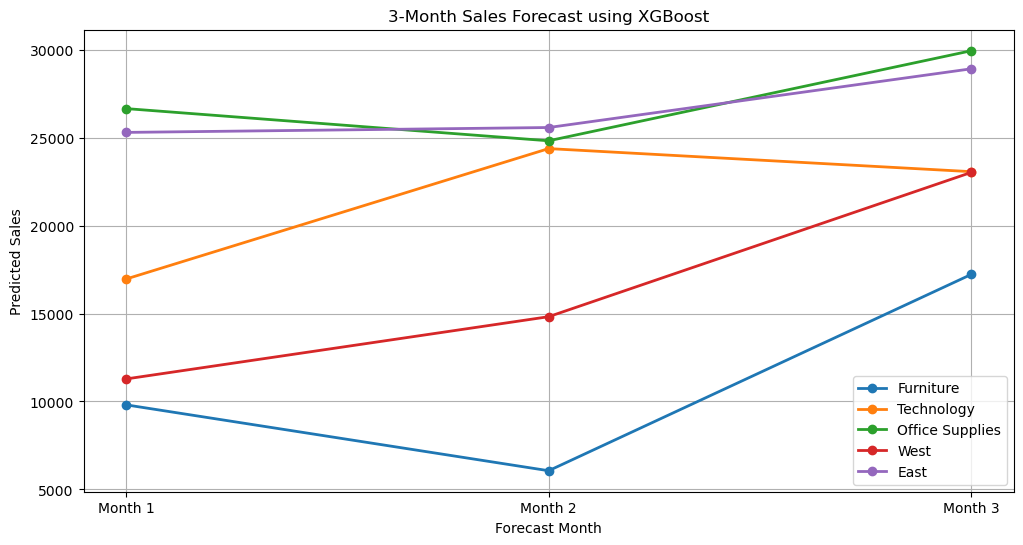

In [54]:
# Forecasts
furniture_forecast = xgboost_forecast(furniture_monthly)
technology_forecast = xgboost_forecast(technology_monthly)
office_forecast = xgboost_forecast(office_monthly)
west_forecast = xgboost_forecast(west_monthly)
east_forecast = xgboost_forecast(east_monthly)

# Forecast Table
forecast_comparison = pd.DataFrame({
    "Month": ["Month 1", "Month 2", "Month 3"],
    "Furniture": furniture_forecast,
    "Technology": technology_forecast,
    "Office Supplies": office_forecast,
    "West": west_forecast,
    "East": east_forecast
})

display(forecast_comparison)

# Plot
plt.figure(figsize=(12,6))

months = ["Month 1", "Month 2", "Month 3"]

plt.plot(months, furniture_forecast, marker="o", linewidth=2, label="Furniture")
plt.plot(months, technology_forecast, marker="o", linewidth=2, label="Technology")
plt.plot(months, office_forecast, marker="o", linewidth=2, label="Office Supplies")
plt.plot(months, west_forecast, marker="o", linewidth=2, label="West")
plt.plot(months, east_forecast, marker="o", linewidth=2, label="East")

plt.title("3-Month Sales Forecast using XGBoost")
plt.xlabel("Forecast Month")
plt.ylabel("Predicted Sales")
plt.grid(True)
plt.legend()

plt.show()

## Insights:-
The results indicate that Office Supplies is expected to remain the highest revenue-generating category over the next three months, while the East region is projected to achieve the strongest regional sales performance. Although the West region shows positive growth toward the end of the forecast horizon, it does not surpass the East region. These forecasts suggest that inventory planning, marketing campaigns, and resource allocation should prioritize the Office Supplies category and the East region to capitalize on the anticipated increase in demand.

## Anamoly Detection in weekly sales data:-

In [55]:
#Creation Weekly Sales Data:-
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.columns = ["Week", "Sales"]

display(weekly_sales.head())
print("Total Weeks :", len(weekly_sales))

,Week,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


Total Weeks : 209


In [56]:
#Isolation Forest
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["IF_Anomaly"] = iso.fit_predict(weekly_sales[["Sales"]])

# -1 = anomaly
weekly_sales["IF_Anomaly"] = weekly_sales["IF_Anomaly"].map(
    {1:0,-1:1}
)

print("Number of anomalies:",
      weekly_sales["IF_Anomaly"].sum())

display(
    weekly_sales[weekly_sales["IF_Anomaly"]==1]
)

Number of anomalies: 11


,Week,Sales,IF_Anomaly
0,2015-01-04,304.508,1
5,2015-02-08,968.534,1
7,2015-02-22,224.912,1
11,2015-03-22,37703.665,1
28,2015-07-19,1387.686,1
36,2015-09-13,29959.137,1
55,2016-01-24,358.522,1
154,2017-12-17,25449.800,1
200,2018-11-04,29017.467,1
202,2018-11-18,30572.447,1


The Isolation Forest algorithm detected several anomalous weeks, including both unusually high and low sales values. Unlike statistical methods, Isolation Forest identifies observations that are isolated from the normal sales distribution without assuming any specific data distribution.
Notable anomalies include:
On 2015-01-04, sales are **304.51**	Very low sales, likely due to the post-holiday period or incomplete sales records at the beginning of the year.
On 2015-02-08, sales are **968.53**	Unusually low weekly demand compared to surrounding weeks.
On 2015-03-22, sales are **37,703.67**	Exceptional sales spike, possibly caused by a promotional campaign, bulk corporate orders, or seasonal demand.

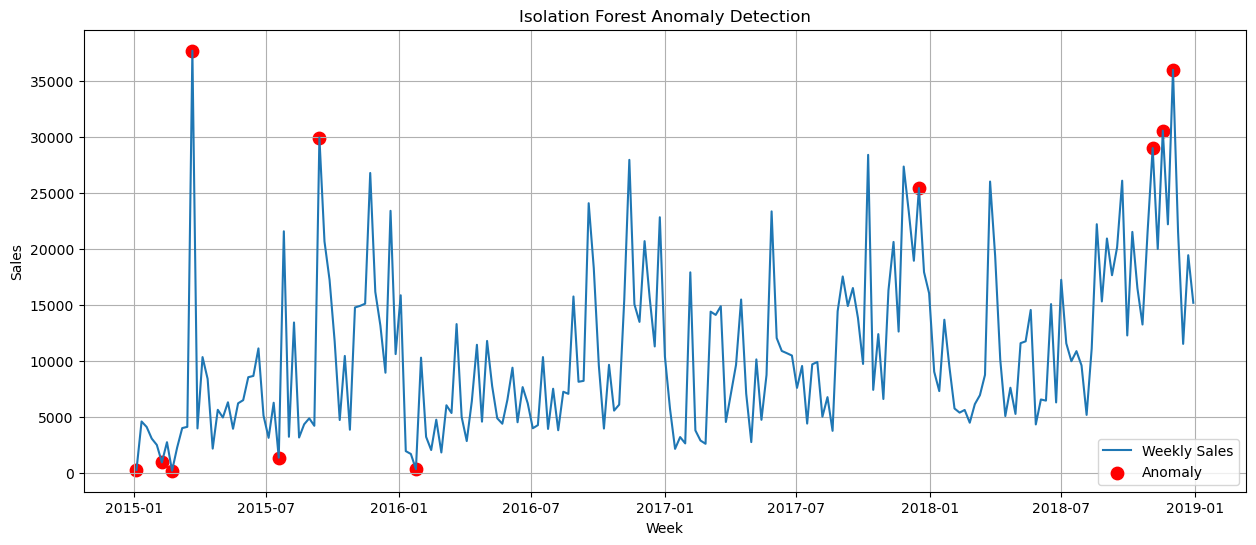

In [57]:
#Isolation Plot
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Week"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

anomaly = weekly_sales[
    weekly_sales["IF_Anomaly"]==1
]

plt.scatter(
    anomaly["Week"],
    anomaly["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Week")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [58]:
# Rolling Z-Score Detection
window = 8

weekly_sales["Rolling_Mean"] = (
    weekly_sales["Sales"]
    .rolling(window)
    .mean()
)

weekly_sales["Rolling_STD"] = (
    weekly_sales["Sales"]
    .rolling(window)
    .std()
)

weekly_sales["Z_Score"] = (
    (weekly_sales["Sales"]-weekly_sales["Rolling_Mean"])
    /weekly_sales["Rolling_STD"]
)

weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z_Score"]
    .abs()>2
)

display(
    weekly_sales[
        weekly_sales["Z_Anomaly"]
    ]
)

,Week,Sales,IF_Anomaly,Rolling_Mean,Rolling_STD,Z_Score,Z_Anomaly
11,2015-03-22,37703.665,1,6832.006500,12546.138409,2.460650,True
29,2015-07-26,21590.080,0,8245.428325,6246.129535,2.136467,True
86,2016-08-28,15773.478,0,7515.302525,4020.682890,2.053924,True
89,2016-09-18,24095.960,0,10251.475400,6524.009519,2.122082,True
125,2017-05-28,23367.662,0,10265.959125,6524.022836,2.008225,True
168,2018-03-25,26029.904,0,8660.308925,7131.467537,2.435627,True


These anomalies mainly represent large positive spikes relative to the local trend rather than extremely low sales.

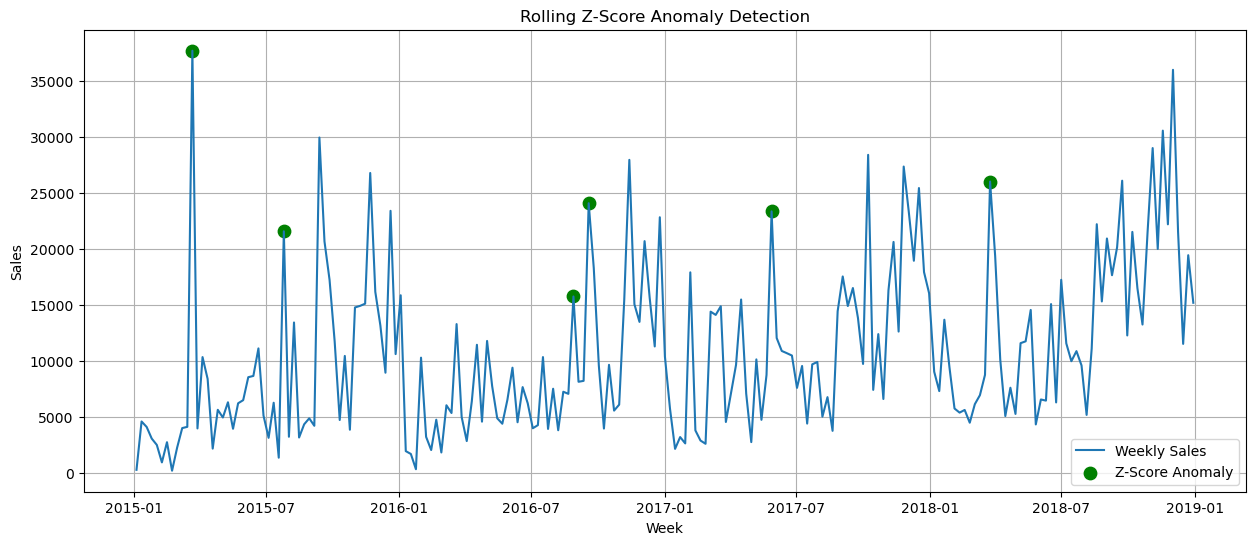

In [59]:
# Z-Score Plot
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Week"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

z = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

plt.scatter(
    z["Week"],
    z["Sales"],
    color="green",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Rolling Z-Score Anomaly Detection")

plt.xlabel("Week")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [60]:
# Compare Methods
comparison = weekly_sales[
    [
        "Week",
        "Sales",
        "IF_Anomaly",
        "Z_Anomaly"
    ]
]

display(
    comparison[
        (comparison["IF_Anomaly"]==1) |
        (comparison["Z_Anomaly"])
    ]
)

,Week,Sales,IF_Anomaly,Z_Anomaly
0,2015-01-04,304.508,1,False
5,2015-02-08,968.534,1,False
7,2015-02-22,224.912,1,False
11,2015-03-22,37703.665,1,True
28,2015-07-19,1387.686,1,False
29,2015-07-26,21590.080,0,True
36,2015-09-13,29959.137,1,False
55,2016-01-24,358.522,1,False
86,2016-08-28,15773.478,0,True
89,2016-09-18,24095.960,0,True


## Final Conclusion
Weekly sales anomalies were detected using both Isolation Forest and the Rolling Z-Score method. While both methods consistently identified the major spike on **22 March 2015**, they disagreed on several other weeks because they rely on different principles for detecting anomalies. Combining machine learning-based and statistical anomaly detection techniques provides a more robust assessment of unusual sales patterns and helps identify periods that may require further business investigation.